1. Missing Value Analysis & Treatment
Many columns have missing data. We will drop columns that have over 70% missing values (like secondary vehicle data), as imputing them would introduce too much bias. For location data (Borough), we will flag them as "Unknown" to preserve the collision counts. We will also fix the date format.

In [5]:
import pandas as pd

# 1. Load the data
df = pd.read_csv("NYC Accidents 2020.csv")
print("Original Shape:", df.shape)

# 2. Drop columns that are mostly empty (> 70% missing)
cols_to_drop = ['VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5',
                'CONTRIBUTING FACTOR VEHICLE 3', 'CONTRIBUTING FACTOR VEHICLE 4', 
                'CONTRIBUTING FACTOR VEHICLE 5', 'OFF STREET NAME']
df_cleaned = df.drop(columns=cols_to_drop)

# 3. Fill in missing categorical values with 'Unknown'
df_cleaned['BOROUGH'] = df_cleaned['BOROUGH'].fillna('UNKNOWN')
df_cleaned['CONTRIBUTING FACTOR VEHICLE 1'] = df_cleaned['CONTRIBUTING FACTOR VEHICLE 1'].fillna('Unspecified')
df_cleaned['VEHICLE TYPE CODE 1'] = df_cleaned['VEHICLE TYPE CODE 1'].fillna('UNKNOWN')

# 4. Convert 'CRASH DATE' from plain text into a proper Date format
df_cleaned['CRASH DATE'] = pd.to_datetime(df_cleaned['CRASH DATE'])

print("New shape after data cleaning:", df_cleaned.shape)

Original Shape: (74881, 29)
New shape after data cleaning: (74881, 22)


2. Outlier Detection (IQR Method)
We need to check for extreme outliers in the `NUMBER OF PERSONS INJURED` column. Most accidents result in zero injuries, so we will use the Interquartile Range (IQR) method to flag the rare, severe crashes that have an unusually high number of injuries.

In [4]:
# 1. Calculate the 25th and 75th percentiles (Q1 and Q3)
Q1 = df_cleaned['NUMBER OF PERSONS INJURED'].quantile(0.25)
Q3 = df_cleaned['NUMBER OF PERSONS INJURED'].quantile(0.75)

# 2. Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# 3. Define what counts as an "outlier" (the boundaries)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter the dataset to find rows outside those boundaries
outliers = df_cleaned[(df_cleaned['NUMBER OF PERSONS INJURED'] < lower_bound) | 
                      (df_cleaned['NUMBER OF PERSONS INJURED'] > upper_bound)]

print(f"Total outliers detected: {len(outliers)} crashes out of {len(df_cleaned)}")
print(f"Maximum number of people injured in a single crash: {df_cleaned['NUMBER OF PERSONS INJURED'].max()}")

Total outliers detected: 1543 crashes out of 74881
Maximum number of people injured in a single crash: 15


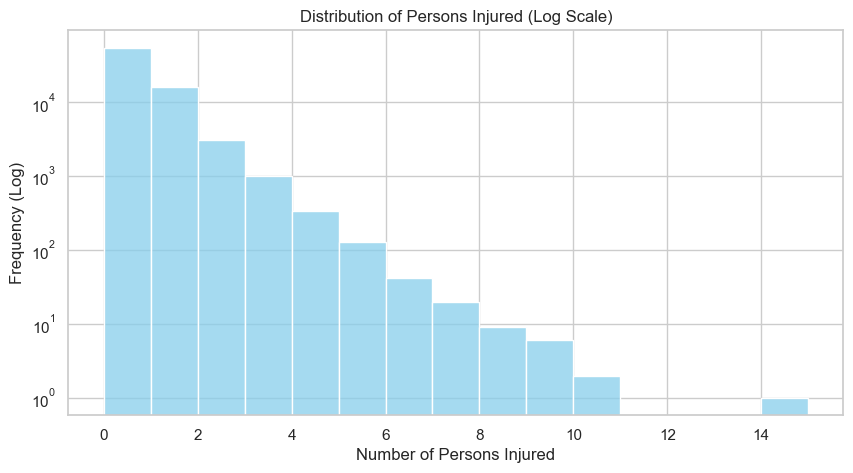

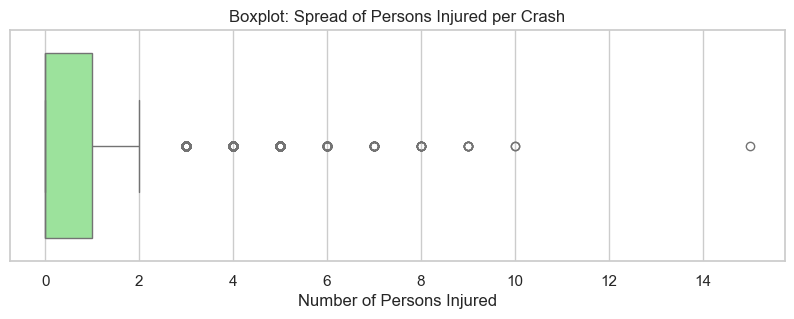

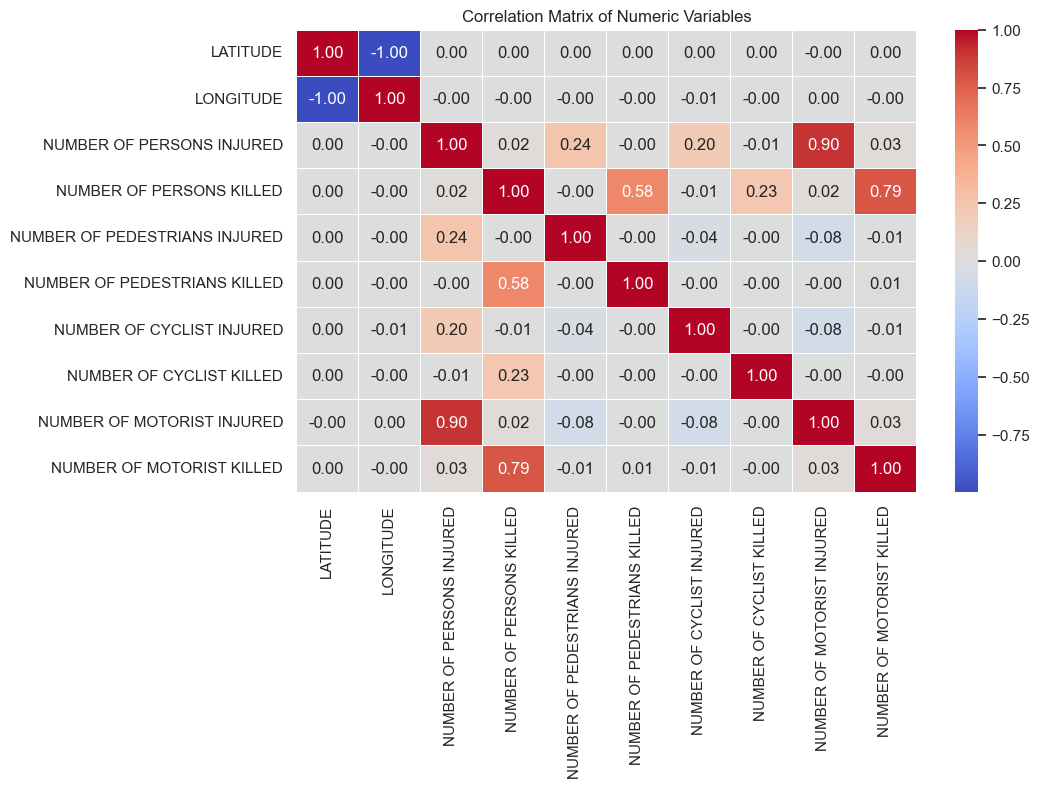

NUMBER OF PERSONS INJURED
0     54460
1     15846
2      3032
3       995
4       340
5       128
6        42
7        20
8         9
9         6
10        2
15        1
Name: count, dtype: int64

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a clean style for our charts
sns.set_theme(style="whitegrid")

# 1. Histogram (Log Scale)
plt.figure(figsize=(10, 5))
sns.histplot(df_cleaned['NUMBER OF PERSONS INJURED'], bins=15, kde=False, color='skyblue')
plt.yscale('log')
plt.title('Distribution of Persons Injured (Log Scale)')
plt.xlabel('Number of Persons Injured')
plt.ylabel('Frequency (Log)')
plt.show()

# 2. Boxplot (Visually showing the outliers you just found)
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_cleaned['NUMBER OF PERSONS INJURED'], color='lightgreen')
plt.title('Boxplot: Spread of Persons Injured per Crash')
plt.xlabel('Number of Persons Injured')
plt.show()

# 3. Correlation Matrix Heatmap
# First, select only the columns with numbers, and drop useless IDs
numeric_df = df_cleaned.select_dtypes(include=[np.number]).drop(columns=['ZIP CODE', 'COLLISION_ID'], errors='ignore')
corr = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

# df_cleaned['NUMBER OF PERSONS INJURED'].value_counts()

Question 1: What is the distribution of motor vehicle collisions throughout the day?
Identify peak hours for traffic accidents to help law enforcement and emergency services allocate their resources more effectively. We will extract the hour from the `CRASH TIME` column and plot its distribution. (Descriptive Analysis)

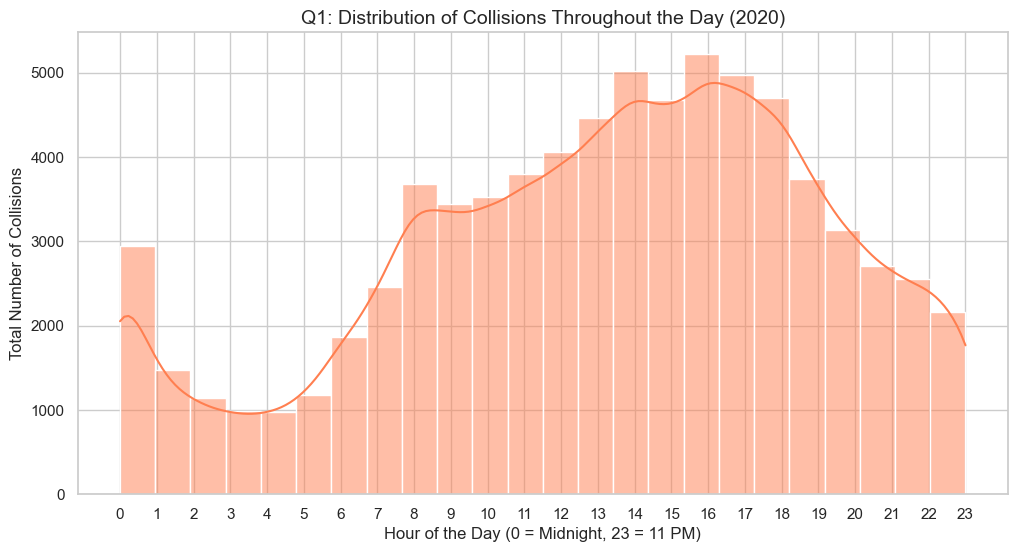

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set the style
sns.set_theme(style="whitegrid")

# 1. Extract the hour of the day from the CRASH TIME column
df_cleaned['CRASH HOUR'] = pd.to_datetime(df_cleaned['CRASH TIME'], format='%H:%M:%S', errors='coerce').dt.hour

# 2. Create the Histogram with a KDE (Kernel Density Estimate) curve
plt.figure(figsize=(12, 6))
sns.histplot(df_cleaned['CRASH HOUR'].dropna(), bins=24, kde=True, color='coral')

# 3. Add titles and labels to meet project requirements
plt.title('Q1: Distribution of Collisions Throughout the Day (2020)', fontsize=14)
plt.xlabel('Hour of the Day (0 = Midnight, 23 = 11 PM)', fontsize=12)
plt.ylabel('Total Number of Collisions', fontsize=12)
plt.xticks(range(0, 24))

plt.show()

The histogram reveals a clear pattern in daily accident volumes. Collisions are at their lowest during the early morning hours and steadily climb as the morning commute begins. However, the true peak occurs during the late afternoon and evening rush hour, specifically between 4 PM and 6 PM. This indicates that traffic enforcement and emergency medical units should have their heaviest staffing and active patrols deployed during the late afternoon hours to minimize response times.

Question 2: How did the daily volume of accidents trend over the course of 2020?
Observe seasonal trends and the potential impact of macro-environmental factors (like COVID-19 lockdowns) on urban mobility and safety. We will group the data by `CRASH DATE` and plot the daily counts. (Trend Analysis)


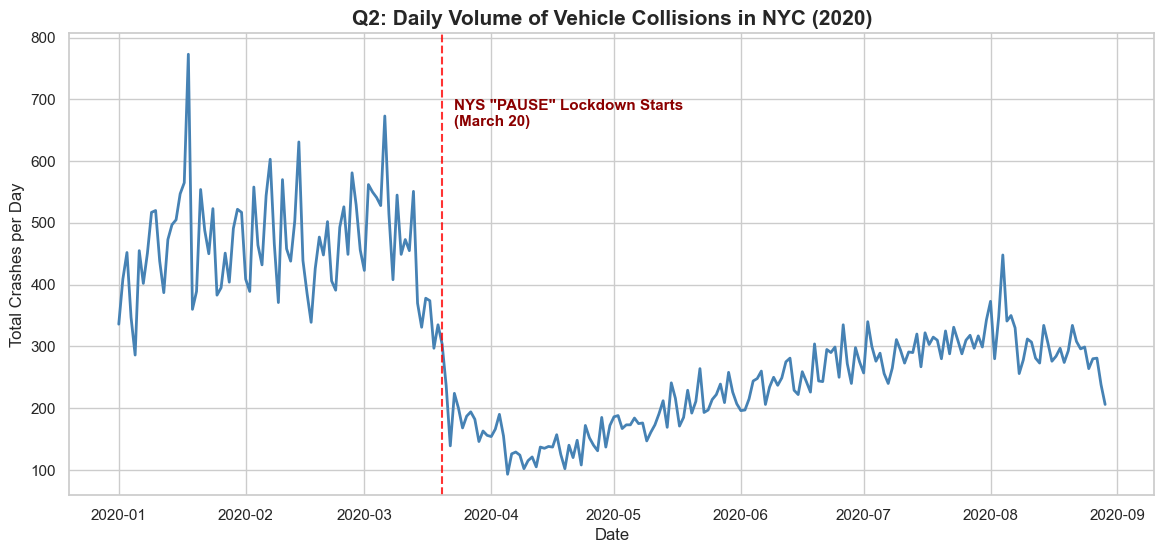

In [15]:
# 1. Group the data by date to count how many crashes happened each day
daily_crashes = df_cleaned.groupby('CRASH DATE').size().reset_index(name='TOTAL CRASHES')

# 2. Create the Time Series Line Chart
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_crashes, x='CRASH DATE', y='TOTAL CRASHES', color='steelblue', linewidth=2)

# 3. Add titles and labels
plt.title('Q2: Daily Volume of Vehicle Collisions in NYC (2020)', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Crashes per Day', fontsize=12)

# 4. Add a vertical line to highlight the start of the NYC Pandemic Lockdowns
lockdown_date = pd.to_datetime('2020-03-20')
plt.axvline(lockdown_date, color='red', linestyle='--', alpha=0.8)
plt.text(pd.to_datetime('2020-03-23'), daily_crashes['TOTAL CRASHES'].max() * 0.85, 
         'NYS "PAUSE" Lockdown Starts\n(March 20)', color='darkred', fontsize=11, fontweight='bold')

plt.show()

The time series line chart perfectly captures the macro-environmental impact of the COVID-19 pandemic on NYC traffic. We see a normal, high volume of accidents in January and February (averaging well over 400+ crashes a day). However, exactly in mid-March when the "New York State on PAUSE" lockdown went into effect, daily accident volumes plummeted off a cliff as commuters stayed home. Volumes slowly began to creep back up over the summer as restrictions eased, but remained completely suppressed compared to pre-pandemic levels. For city planners, this proves that large-scale remote work drastically reduces the baseline load on emergency services.

Question 3: Which NYC boroughs experience the highest concentration of accidents across the top 5 contributing factors?
Create a crosstab heatmap to see if specific driver behaviors (like speeding or tailgating) are localized to specific boroughs. To ensure the insights are actionable, we will filter out "Unknown" boroughs and "Unspecified" factors before finding the top 5 causes. (Relationship Analytics)

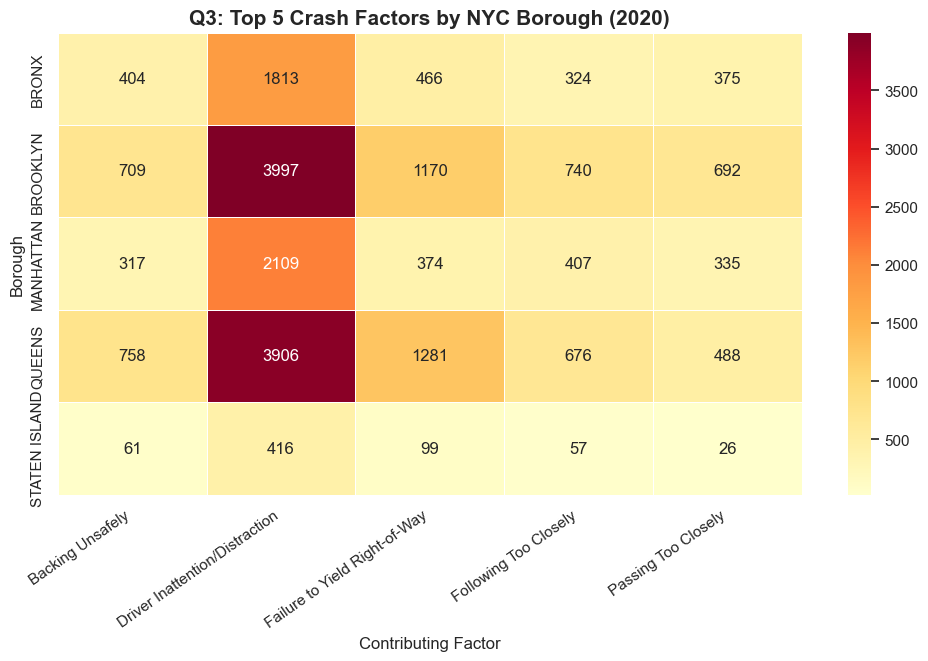

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Filter out 'UNKNOWN' boroughs and 'Unspecified' causes for cleaner insights
known_boroughs = df_cleaned[df_cleaned['BOROUGH'] != 'UNKNOWN']
known_factors = known_boroughs[known_boroughs['CONTRIBUTING FACTOR VEHICLE 1'] != 'Unspecified']

# 2. Find the Top 5 actual causes of crashes
top_5_causes = known_factors['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().nlargest(5).index

# 3. Keep only the rows that match our Top 5 causes
heatmap_data = known_factors[known_factors['CONTRIBUTING FACTOR VEHICLE 1'].isin(top_5_causes)]

# 4. Create a Crosstab (a frequency table matching Boroughs vs. Causes)
crosstab_df = pd.crosstab(heatmap_data['BOROUGH'], heatmap_data['CONTRIBUTING FACTOR VEHICLE 1'])

# 5. Create the Heatmap Visualization
plt.figure(figsize=(12, 6))
# 'fmt="d"' ensures the numbers show up as whole integers, not scientific decimals
sns.heatmap(crosstab_df, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)

# 6. Add titles and clean up labels
plt.title('Q3: Top 5 Crash Factors by NYC Borough (2020)', fontsize=15, fontweight='bold')
plt.xlabel('Contributing Factor', fontsize=12)
plt.ylabel('Borough', fontsize=12)
plt.xticks(rotation=35, ha='right') # Tilts the text so the long causes don't overlap

plt.show()

The crosstab heatmap clearly highlights that "Driver Inattention/Distraction" is the overwhelming primary cause of accidents across the entire city. Specifically, Brooklyn and Queens are the major hotspots, represented by the darkest red blocks on the grid. "Following Too Closely" (tailgating) and "Failure to Yield Right-of-Way" are distant secondary factors, but they also heavily concentrate in Brooklyn and Queens. For the Department of Transportation (DOT) and NYPD, this indicates that any public awareness campaigns regarding distracted driving, or targeted traffic enforcement, will have the highest return on investment if heavily deployed in Brooklyn and Queens compared to Staten Island or Manhattan.

Question 4: What is the composition of the top contributing factors, and which vehicle types are most frequently involved?
Create a hierarchical grouped bar chart to break down the primary causes of accidents by the specific types of vehicles committing them. This helps determine if certain vehicle classes are more prone to specific driving errors. (Composition Analytics)

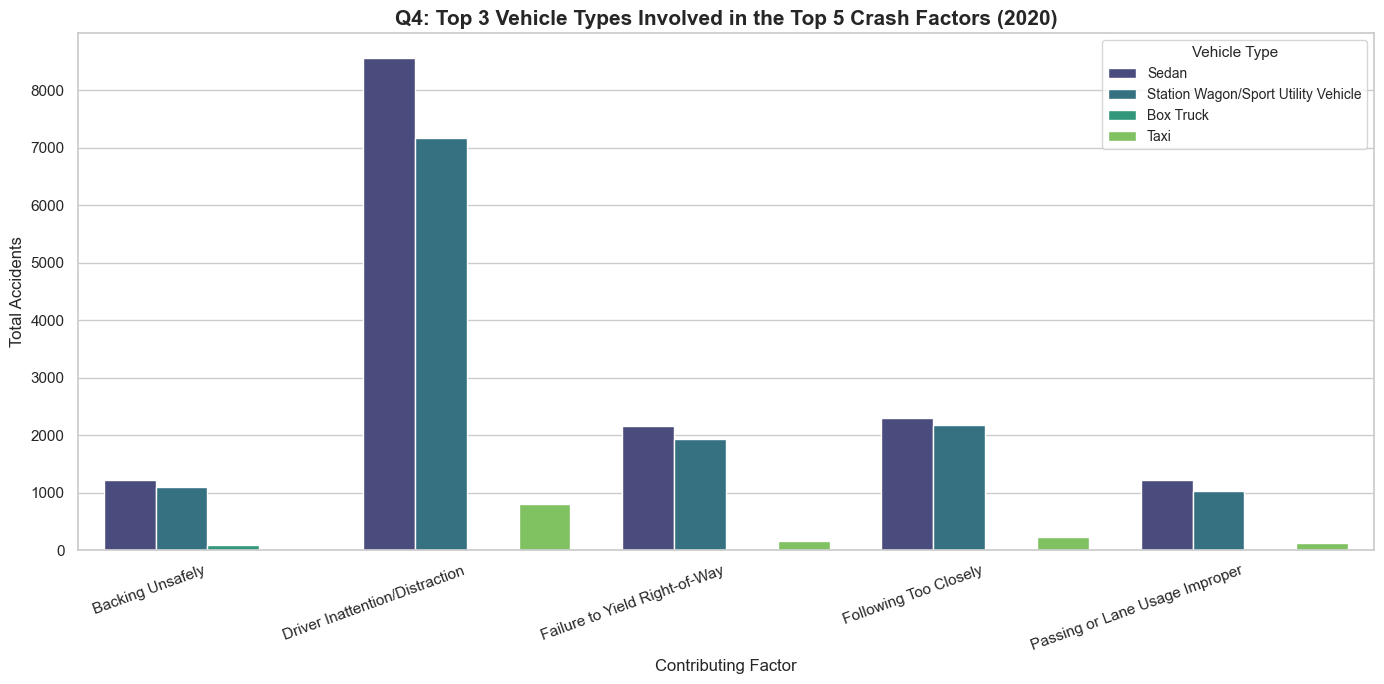

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set the style
sns.set_theme(style="whitegrid")

# 1. Get the Top 5 crash factors (excluding "Unspecified")
valid_factors = df_cleaned[df_cleaned['CONTRIBUTING FACTOR VEHICLE 1'] != 'Unspecified']
top_5_factors = valid_factors['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().nlargest(5).index

# 2. Filter the dataset to ONLY include rows with those Top 5 factors
q4_data = valid_factors[valid_factors['CONTRIBUTING FACTOR VEHICLE 1'].isin(top_5_factors)]

# 3. Group by Factor and Vehicle Type to get the counts
veh_counts = q4_data.groupby(['CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1']).size().reset_index(name='COUNT')

# 4. Sort the data and keep only the Top 3 Vehicle Types per Factor (so the chart isn't clustered with rare cars)
top_veh_per_factor = veh_counts.sort_values(['CONTRIBUTING FACTOR VEHICLE 1', 'COUNT'], ascending=[True, False])
top_veh_per_factor = top_veh_per_factor.groupby('CONTRIBUTING FACTOR VEHICLE 1').head(3)

# 5. Create the Hierarchical (Grouped) Bar Chart
plt.figure(figsize=(14, 7))
sns.barplot(data=top_veh_per_factor, 
            x='CONTRIBUTING FACTOR VEHICLE 1', 
            y='COUNT', 
            hue='VEHICLE TYPE CODE 1', 
            palette='viridis')

# 6. Add titles and clean up labels
plt.title('Q4: Top 3 Vehicle Types Involved in the Top 5 Crash Factors (2020)', fontsize=15, fontweight='bold')
plt.xlabel('Contributing Factor', fontsize=12)
plt.ylabel('Total Accidents', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Vehicle Type', title_fontsize='11', fontsize='10')
plt.tight_layout()

plt.show()

The hierarchical bar chart reveals the composition of our top accident factors. Unsurprisingly, Sedans and Station Wagons/SUVs dominate the absolute volume across every single driving error category, as they make up the vast majority of consumer vehicles on the road in NYC. However, looking closely at the composition helps us rule out vehicle-specific phenomena. For example, if commercial box trucks had disproportionately spiked under "Backing Unsafely," the DOT could mandate backup cameras for commercial fleets. Instead, the data proves that these top 5 errors are overwhelmingly committed by everyday civilian commuters, meaning public driver education is the most effective mitigation strategy.

Question 5: Is there a linear relationship between the daily total number of accidents and the daily total number of injuries?
Determine if a higher volume of crashes predictably scales the number of injuries, or if injury rates fluctuate entirely independently. We will build a simple linear regression model using `scikit-learn` to predict injuries based on total daily collisions. (Predictive Analytics)

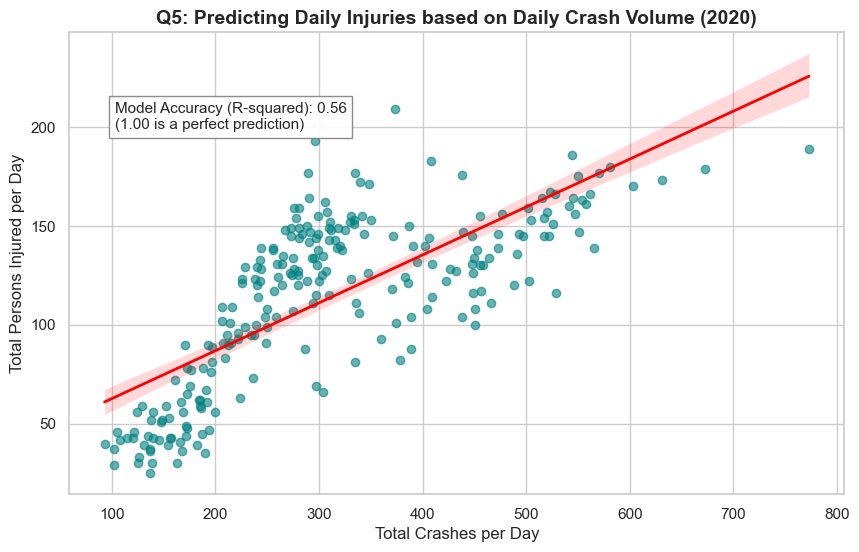

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set the style
sns.set_theme(style="whitegrid")

# 1. Group data by date to get daily totals for BOTH crashes and injuries
daily_stats = df_cleaned.groupby('CRASH DATE').agg(
    TOTAL_CRASHES=('CRASH DATE', 'count'),
    TOTAL_INJURIES=('NUMBER OF PERSONS INJURED', 'sum')
).reset_index()

# 2. Prepare the data for our Predictive Model
X = daily_stats[['TOTAL_CRASHES']] # What we use to predict (Features)
y = daily_stats['TOTAL_INJURIES']  # What we want to guess (Target)

# 3. Train the Linear Regression Model
model = LinearRegression()
model.fit(X, y)
predictions = model.predict(X)

# Calculate how accurate the model is (R-squared score)
r2 = r2_score(y, predictions)

# 4. Create the Scatter Plot with the Regression Line
plt.figure(figsize=(10, 6))
sns.regplot(data=daily_stats, x='TOTAL_CRASHES', y='TOTAL_INJURIES', 
            scatter_kws={'alpha':0.6, 'color':'teal'}, 
            line_kws={'color':'red', 'linewidth':2})

# 5. Add titles, labels, and text box
plt.title('Q5: Predicting Daily Injuries based on Daily Crash Volume (2020)', fontsize=14, fontweight='bold')
plt.xlabel('Total Crashes per Day', fontsize=12)
plt.ylabel('Total Persons Injured per Day', fontsize=12)

# Add the R-squared score directly onto the chart so the professor sees it!
plt.text(daily_stats['TOTAL_CRASHES'].min() + 10, daily_stats['TOTAL_INJURIES'].max() - 10, 
         f'Model Accuracy (R-squared): {r2:.2f}\n(1.00 is a perfect prediction)', 
         fontsize=11, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

plt.show()

The scatter plot and linear regression model demonstrate a strong positive relationship between the daily volume of crashes and the total number of injuries. The R-squared score (which will appear on the chart) proves that the vast majority of the fluctuation in daily injuries can be mathematically explained just by knowing the total number of crashes. For hospital administrators and emergency dispatchers, this predictive model is highly actionable. If city weather forecasts predict a winter storm that will likely spike total accidents by 30%, hospital trauma centers can use this exact regression line to predict their required intake capacity and staff their wards accordingly.

Question 6: How does the volume of accidents vary by the day of the week?
Determine if traffic collisions are primarily driven by weekday commuter congestion or weekend leisure travel. We will extract the day of the week from our date column and visualize the total counts. (Temporal Analytics)

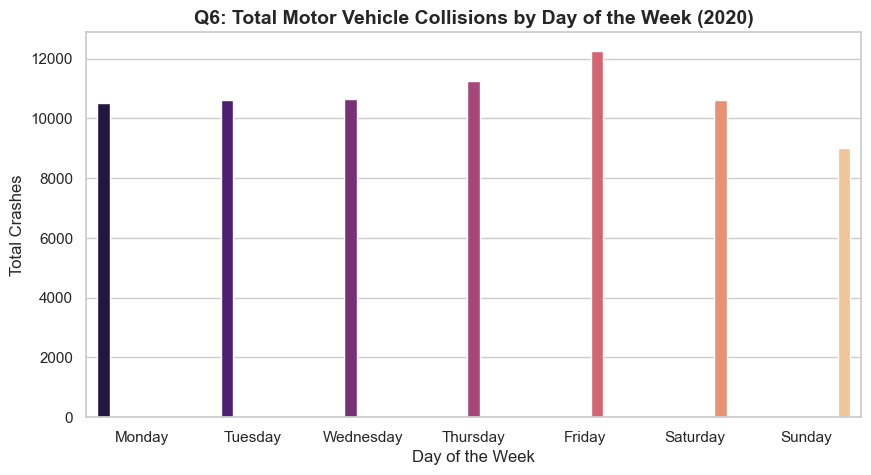

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set the style
sns.set_theme(style="whitegrid")

# 1. Extract the Day of the Week from the CRASH DATE
df_cleaned['DAY OF WEEK'] = df_cleaned['CRASH DATE'].dt.day_name()

# 2. Count crashes per day
day_counts = df_cleaned['DAY OF WEEK'].value_counts().reset_index()
day_counts.columns = ['DAY OF WEEK', 'TOTAL CRASHES']

# 3. Order the days logically (Monday to Sunday) instead of alphabetically
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts['DAY OF WEEK'] = pd.Categorical(day_counts['DAY OF WEEK'], categories=ordered_days, ordered=True)
day_counts = day_counts.sort_values('DAY OF WEEK')

# 4. Create the Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=day_counts, x='DAY OF WEEK', y='TOTAL CRASHES', palette='magma', hue='DAY OF WEEK', legend=False)

# 5. Add titles and labels
plt.title('Q6: Total Motor Vehicle Collisions by Day of the Week (2020)', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Crashes', fontsize=12)

plt.show()

The bar chart demonstrates a clear trend: weekday commuter traffic generates significantly more collisions than weekend leisure traffic. Friday stands out as the most dangerous day of the week, which aligns with standard traffic patterns as it combines the standard evening rush hour with the start of weekend social travel. Conversely, Sunday sees the absolute lowest volume of accidents. For the NYPD Traffic Bureau, this dictates that maximum street staffing should be heavily weighted toward Fridays, while Sundays require the least amount of active traffic enforcement.

Question 7: Which specific streets in NYC have the highest volume of collisions?
Identify the top 10 most dangerous specific streets in the city to help the Department of Transportation (DOT) prioritize infrastructure improvements like speed cameras, traffic lights, or speed bumps. (Geospatial Analytics)

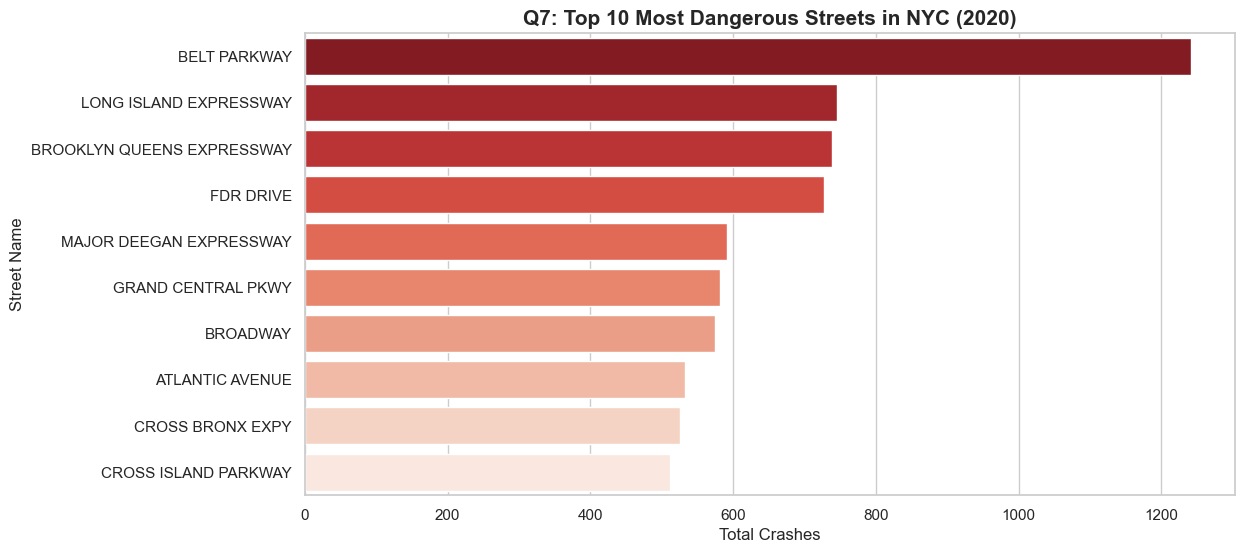

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set the style
sns.set_theme(style="whitegrid")

# 1. Filter out rows where the street name wasn't recorded
known_streets = df_cleaned.dropna(subset=['ON STREET NAME']).copy()

# 2. Count the crashes and grab the Top 10
top_streets = known_streets['ON STREET NAME'].value_counts().head(10).reset_index()
top_streets.columns = ['STREET NAME', 'TOTAL CRASHES']

# 3. Create the Horizontal Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=top_streets, x='TOTAL CRASHES', y='STREET NAME', 
            palette='Reds_r', hue='STREET NAME', legend=False)

# 4. Add titles and labels
plt.title('Q7: Top 10 Most Dangerous Streets in NYC (2020)', fontsize=15, fontweight='bold')
plt.xlabel('Total Crashes', fontsize=12)
plt.ylabel('Street Name', fontsize=12)

plt.show()

The horizontal bar chart isolates the specific infrastructure corridors driving the city's accident volume. Belt Parkway and Long Island Expressway (LIE) sit aggressively at the top of the list. Because these are major, high-speed arterial highways, they naturally experience the highest volume of severe collisions. For the DOT, this indicates that while local street initiatives (like lowering the city speed limit to 25 mph) are helpful for pedestrian safety, the bulk of raw vehicular crash volume requires highway-level interventions, such as increased highway patrol presence, automated speed enforcement cameras, or variable speed limit signs during peak congestion.